[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/vae-mnist.ipynb)

# Variational Autoencoder (VAE) on MNIST

This notebook trains a simple VAE to learn a compressed representation of handwritten digits, then generates new digit images by sampling from the learned latent space.

Now we'll import the necessary libraries and enable autoreload.

In [ ]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as L
import matplotlib.pyplot as plt
import numpy as np
import wandb
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Import shared utilities from local package
from aiml_notebooks import create_trainer, plot_image_grid, log_images_to_wandb

# Enable autoreload for hot reloading
%load_ext autoreload
%autoreload 2

print(f"PyTorch: {torch.__version__}")
print(f"Lightning: {L.__version__}")

Next, we'll define all hyperparameters in a CONFIG dictionary and set random seeds for reproducibility.

In [2]:
# Configuration (Base defaults - can be overridden by papermill parameters)
CONFIG = {
    # Data
    'seed': 42,                      # Random seed for reproducibility
    'batch_size': 128,               # Number of images per batch
    'num_workers': 4,                # Parallel data loading workers
    
    # Model
    'latent_dim': 20,                # Size of compressed latent representation
    'hidden_dims': [32, 64],         # Conv layer channels (encoder/decoder)
    'learning_rate': 1e-3,           # Step size for optimizer (0.001)
    
    # Training
    'max_epochs': 50,                # Number of complete passes through data
    'log_every_n_steps': 50,         # How often to log training metrics
    
    # Loss weights
    'kl_weight': 1.0,                # Weight for KL divergence term
    
    # Visualization
    'num_samples': 16,               # Number of images to generate
    
    # Weights & Biases
    'wandb_project': 'vae-mnist',    # W&B project name
    'wandb_run_name': None,          # Optional run name (None = auto-generated)
}

# Set random seeds
L.seed_everything(CONFIG['seed'])

Seed set to 42


42

Now we'll load the MNIST dataset and create data loaders for training and validation.

In [3]:
# MNIST dataset with normalization to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download and load datasets
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

val_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers']
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers']
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

Train samples: 60000
Val samples: 10000
Image shape: torch.Size([1, 28, 28])


Now we'll define the VAE model with encoder (image → latent), reparameterization trick, and decoder (latent → image).

In [4]:
# Variational Autoencoder with convolutional encoder/decoder
class VAE(L.LightningModule):
    def __init__(self, latent_dim=20, hidden_dims=[32, 64], learning_rate=1e-3, kl_weight=1.0):
        super().__init__()
        self.save_hyperparameters()
        
        # Encoder: 28x28 -> 7x7x64 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, hidden_dims[0], kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(hidden_dims[0], hidden_dims[1], kernel_size=3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.ReLU(),
            nn.Flatten(),
        )
        
        # Calculate flattened size: 7*7*hidden_dims[1]
        self.flatten_size = 7 * 7 * hidden_dims[1]
        
        # Latent space projections
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        
        # Decoder: latent_dim -> 7x7x64 -> 28x28
        self.decoder_input = nn.Linear(latent_dim, self.flatten_size)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dims[1], hidden_dims[0], kernel_size=3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dims[0], 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid(),  # Output in [0, 1] range
        )
    
    def encode(self, x):
        """Encode image to latent mean and log-variance."""
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = mu + sigma * epsilon."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        """Decode latent vector to image."""
        h = self.decoder_input(z)
        h = h.view(-1, self.hparams.hidden_dims[1], 7, 7)
        return self.decoder(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    
    def loss_function(self, recon, x, mu, logvar):
        """VAE loss = reconstruction loss + KL divergence."""
        # Reconstruction loss (binary cross-entropy)
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
        
        # KL divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        # Total loss (normalized by batch size)
        total_loss = (recon_loss + self.hparams.kl_weight * kl_loss) / x.size(0)
        
        return total_loss, recon_loss / x.size(0), kl_loss / x.size(0)
    
    def training_step(self, batch, batch_idx):
        x, _ = batch
        recon, mu, logvar = self(x)
        loss, recon_loss, kl_loss = self.loss_function(recon, x, mu, logvar)
        
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_recon_loss', recon_loss)
        self.log('train_kl_loss', kl_loss)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, _ = batch
        recon, mu, logvar = self(x)
        loss, recon_loss, kl_loss = self.loss_function(recon, x, mu, logvar)
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_recon_loss', recon_loss)
        self.log('val_kl_loss', kl_loss)
        
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
    
    @torch.no_grad()
    def sample(self, num_samples=16):
        """Generate new images by sampling from the latent space."""
        self.eval()
        z = torch.randn(num_samples, self.hparams.latent_dim, device=self.device)
        samples = self.decode(z)
        return samples

# Initialize model
model = VAE(
    latent_dim=CONFIG['latent_dim'],
    hidden_dims=CONFIG['hidden_dims'],
    learning_rate=CONFIG['learning_rate'],
    kl_weight=CONFIG['kl_weight'],
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 228,905


Now we'll train the model using PyTorch Lightning's Trainer with W&B logging.

In [ ]:
# Train the model (W&B logger created automatically)
trainer = create_trainer(
    max_epochs=CONFIG['max_epochs'],
    log_every_n_steps=CONFIG['log_every_n_steps'],
    wandb_project=CONFIG['wandb_project'],
    wandb_run_name=CONFIG['wandb_run_name'],
    wandb_config=CONFIG,
    model=model
)
trainer.fit(model, train_loader, val_loader)

Finally, we'll visualize reconstructions and generate new digits by sampling from the latent space.

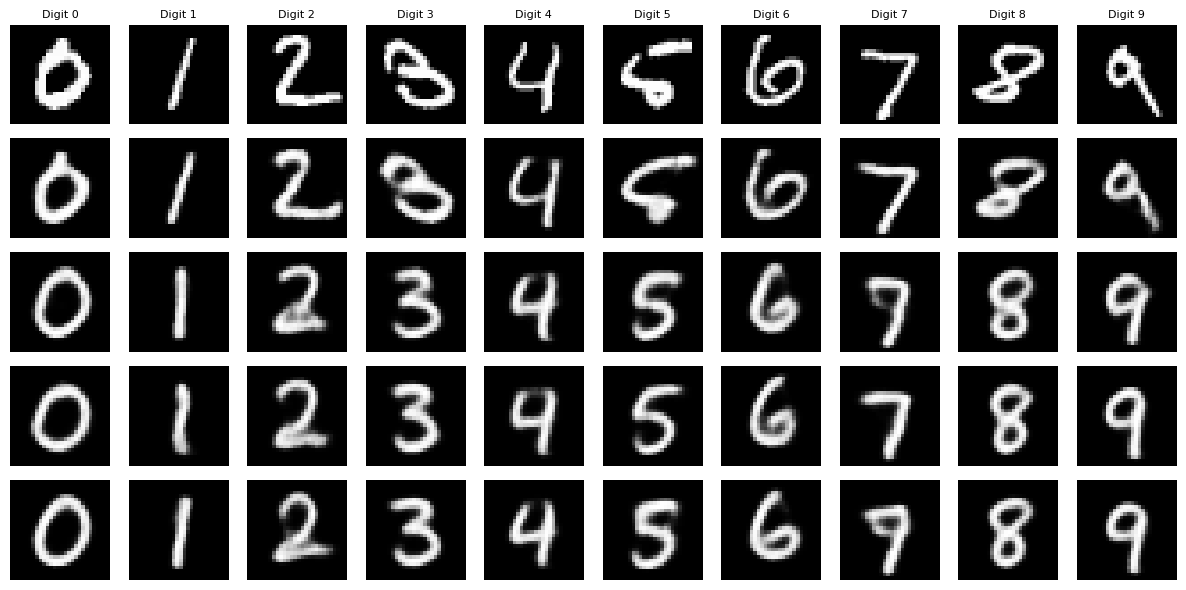


VAE RESULTS
Columns: Digits 0-9 (in order)
Row 1: Original test images
Row 2: Reconstructions (VAE output)
Rows 3-5: Diverse samples from each digit's latent space cluster


In [6]:
# Get test images for each digit 0-9
model.eval()

# Collect multiple examples of each digit from validation set
digit_examples = {i: [] for i in range(10)}
for images, labels in val_loader:
    for img, label in zip(images, labels):
        digit = label.item()
        if len(digit_examples[digit]) < 100:  # Collect 100 examples per digit
            digit_examples[digit].append(img)
    if all(len(examples) >= 100 for examples in digit_examples.values()):
        break

# Get one representative image per digit for display
test_images = torch.stack([digit_examples[i][0] for i in range(10)])

# Compute mean latent vectors for each digit class
with torch.no_grad():
    # Encode all examples of each digit to find the cluster center
    digit_latent_means = []
    digit_latent_stds = []
    
    for digit in range(10):
        digit_batch = torch.stack(digit_examples[digit]).to(model.device)
        mu, logvar = model.encode(digit_batch)
        
        # Compute mean and std of the latent distribution for this digit
        digit_latent_means.append(mu.mean(dim=0))
        digit_latent_stds.append(torch.exp(0.5 * logvar).mean(dim=0))
    
    digit_latent_means = torch.stack(digit_latent_means)
    digit_latent_stds = torch.stack(digit_latent_stds)
    
    # Reconstruct the representative images
    test_images_gpu = test_images.to(model.device)
    reconstructions, _, _ = model(test_images_gpu)
    
    # Generate 3 variations of each digit by sampling from the digit's latent cluster
    generated_rows = []
    for _ in range(3):
        # Sample from the latent space around each digit's mean with its learned std
        eps = torch.randn_like(digit_latent_means)
        z = digit_latent_means + digit_latent_stds * eps
        samples = model.decode(z)
        generated_rows.append(samples)
    
    generated = torch.cat(generated_rows, dim=0)

# Move to CPU for plotting
test_images = test_images.cpu()
reconstructions = reconstructions.cpu()
generated = generated.cpu()

# Stack all images: [Original (10) | Reconstruction (10) | Generated row 1 (10) | Generated row 2 (10) | Generated row 3 (10)]
all_images = torch.cat([test_images, reconstructions, generated], dim=0)

# Create column labels for digits 0-9
col_labels = [f'Digit {i}' for i in range(10)]

# Plot using shared utility (5 rows × 10 columns)
fig = plot_image_grid(
    images=all_images,
    nrows=5,
    ncols=10,
    row_labels=['Original', 'Reconstructed', 'Generated #1', 'Generated #2', 'Generated #3'],
    col_labels=col_labels,
    figsize=(12, 6),
    cmap='gray'
)
plt.show()

# Log to W&B
log_images_to_wandb(fig, 'reconstructions')

print("\n" + "="*50)
print("VAE RESULTS")
print("="*50)
print(f"Columns: Digits 0-9 (in order)")
print(f"Row 1: Original test images")
print(f"Row 2: Reconstructions (VAE output)")
print(f"Rows 3-5: Diverse samples from each digit's latent space cluster")